# 03 — Product Trend Prediction Model
Train a classification model to predict whether a product will trend in a specific region.
Output: `model_trending.pkl`, `encoders.pkl`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style='darkgrid')
print('✅ Library is Ready')

✅ Library is Ready


## 1. Load & Prepare Data

In [2]:
df = pd.read_csv('../Data/Processed/ecommerce_clean.csv')
df['profit_margin'] = df['profit'] / df['sales']
df['revenue_per_unit'] = df['sales'] / df['quantity']

print(f'Total data: {len(df):,} line')
print(f"\nDistribution target (is_trending):")
print(df['is_trending'].value_counts())
print(f"\nBalance ratio: {df['is_trending'].mean()*100:.1f}% trending")

Total data: 5,000 line

Distribution target (is_trending):
is_trending
0    2997
1    2003
Name: count, dtype: int64

Balance ratio: 40.1% trending


## 2. Trend-Specific EDA

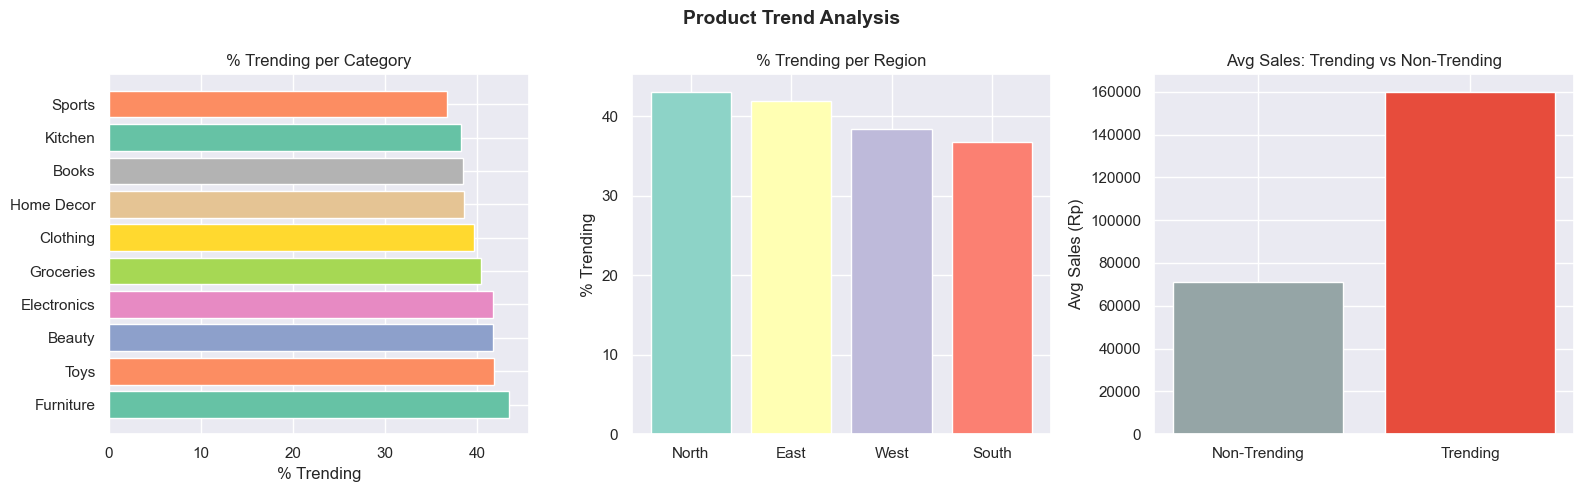

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Trending per Category
trend_cat = df.groupby('category')['is_trending'].mean().sort_values(ascending=False)
axes[0].barh(trend_cat.index, trend_cat.values * 100, color=sns.color_palette('Set2'))
axes[0].set_xlabel('% Trending')
axes[0].set_title('% Trending per Category')

# Trending per Region
trend_reg = df.groupby('region')['is_trending'].mean().sort_values(ascending=False)
axes[1].bar(trend_reg.index, trend_reg.values * 100, color=sns.color_palette('Set3'))
axes[1].set_ylabel('% Trending')
axes[1].set_title('% Trending per Region')

# Avg sales: trending vs not trending
comp = df.groupby('is_trending')['sales'].mean()
axes[2].bar(['Non-Trending', 'Trending'], comp.values, color=['#95a5a6','#e74c3c'])
axes[2].set_ylabel('Avg Sales (Rp)')
axes[2].set_title('Avg Sales: Trending vs Non-Trending')

plt.suptitle('Product Trend Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Encoding & Feature Selection

In [4]:
le_dict = {}
cat_cols = ['region', 'city', 'category', 'sub_category', 'payment_mode']
df_enc = df.copy()

for col in cat_cols:
    le = LabelEncoder()
    df_enc[col + '_enc'] = le.fit_transform(df[col])
    le_dict[col] = le
    print(f'  ✅ {col}: {le.classes_.tolist()}')

FEATURES = [
    'quantity', 'unit_price', 'discount', 'month', 'year',
    'profit_margin', 'revenue_per_unit',
    'region_enc', 'city_enc', 'category_enc', 'sub_category_enc', 'payment_mode_enc'
]

X = df_enc[FEATURES]
y = df_enc['is_trending']
print(f'\nNumber of features: {len(FEATURES)}')
print(f'Shape X: {X.shape}, y: {y.shape}')

  ✅ region: ['East', 'North', 'South', 'West']
  ✅ city: ['Ahmedabad', 'Amritsar', 'Bangalore', 'Bhubaneswar', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Goa', 'Guwahati', 'Hyderabad', 'Jaipur', 'Kolkata', 'Lucknow', 'Mumbai', 'Patna', 'Pune', 'Ranchi', 'Surat', 'Thiruvananthapuram']
  ✅ category: ['Beauty', 'Books', 'Clothing', 'Electronics', 'Furniture', 'Groceries', 'Home Decor', 'Kitchen', 'Sports', 'Toys']
  ✅ sub_category: ['Accessories', 'Action Figure', 'Bed', 'Biography', 'Board Game', 'Cabinet', 'Camera', 'Chair', 'Clock', 'Comics', 'Cookware Set', 'Cricket Bat', 'Cushion', 'Doll', 'Dumbbells', 'Face Cream', 'Fiction', 'Football', 'Foundation', 'Headphones', 'Juicer', 'Kids Wear', 'Lamp', 'Laptop', 'Lipstick', "Men's Wear", 'Microwave', 'Mixer Grinder', 'Mobile', 'Non-Fiction', 'Oil', 'Perfume', 'Puzzle', 'RC Car', 'Refrigerator', 'Rice', 'Shampoo', 'Shoes', 'Smartwatch', 'Sofa', 'Spices', 'Sugar', 'Table', 'Tennis Racket', 'Textbook', 'Vase', 'Wall Art', 'Wheat', "Wome

## 4. Split Data

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]:,} line')
print(f'Test : {X_test.shape[0]:,} line')
print(f'Rasio trending in train: {y_train.mean()*100:.1f}%')
print(f'Rasio trending in test : {y_test.mean()*100:.1f}%')

Train: 4,000 line
Test : 1,000 line
Rasio trending in train: 40.1%
Rasio trending in test : 40.1%


## 5. Training & Model Comparison

In [6]:
models = {
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    cv  = cross_val_score(model, X, y, cv=5, scoring='roc_auc').mean()
    results[name] = {'model': model, 'y_pred': y_pred, 'auc': auc, 'cv': cv}
    print(f'[{name}]  AUC-Test: {auc:.4f}  |  CV-AUC: {cv:.4f}')

[Random Forest]  AUC-Test: 1.0000  |  CV-AUC: 1.0000
[Gradient Boosting]  AUC-Test: 1.0000  |  CV-AUC: 1.0000
[Logistic Regression]  AUC-Test: 1.0000  |  CV-AUC: 1.0000


## 6. Best Model Evaluation

In [7]:
best_name = max(results, key=lambda x: results[x]['auc'])
best_model = results[best_name]['model']
y_pred_best = results[best_name]['y_pred']

print(f'🏆 Best Model: {best_name}')
print(f'   AUC-ROC: {results[best_name]["auc"]:.4f}')
print()
print(classification_report(y_test, y_pred_best, target_names=['Non-Trending', 'Trending']))

🏆 Best Model: Random Forest
   AUC-ROC: 1.0000

              precision    recall  f1-score   support

Non-Trending       1.00      1.00      1.00       599
    Trending       1.00      1.00      1.00       401

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



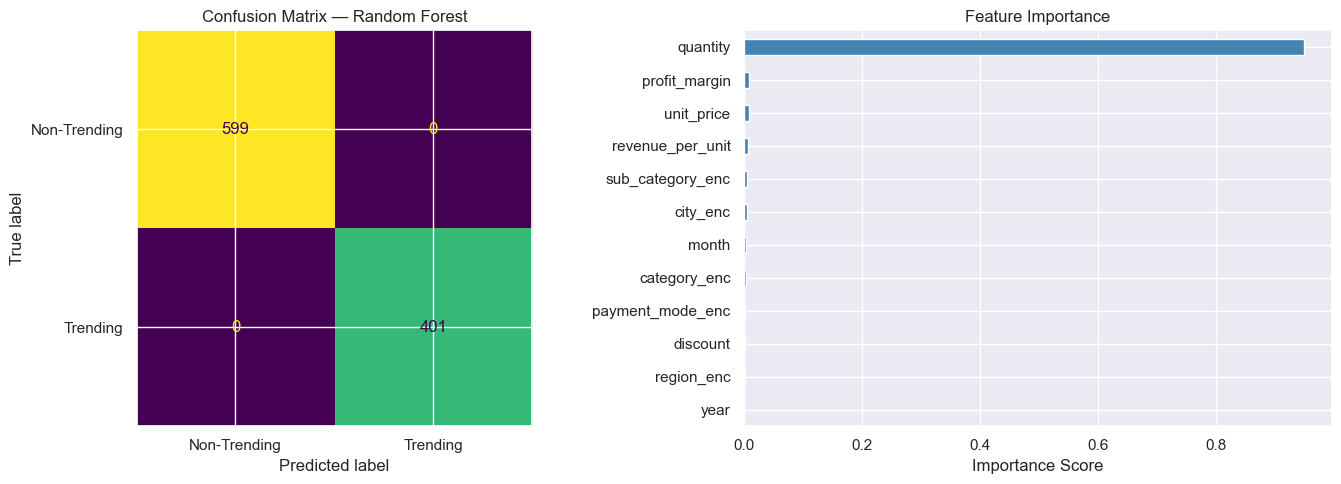

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_best),
                       display_labels=['Non-Trending','Trending']).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'Confusion Matrix — {best_name}')

# Feature Importance
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values()
    fi.plot(kind='barh', ax=axes[1], color='steelblue')
    axes[1].set_title('Feature Importance')
    axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

## 7. Save Models & Encoders

In [9]:
with open('../Notebooks/model_trending.pkl', 'wb') as f:
    pickle.dump({'model': best_model, 'features': FEATURES}, f)

with open('../Notebooks/encoders.pkl', 'wb') as f:
    pickle.dump(le_dict, f)

with open('../Notebooks/label_encoder.pkl', 'wb') as f:
    pickle.dump(le_dict, f)

print('✅ Saved:')
print('   📦 model_trending.pkl')
print('   📦 encoders.pkl')
print('   📦 label_encoder.pkl')

✅ Saved:
   📦 model_trending.pkl
   📦 encoders.pkl
   📦 label_encoder.pkl
